# 📊 Seaborn Visualization & Styling in Python

This notebook demonstrates various visualization tools provided by Seaborn for EDA (Exploratory Data Analysis), including:

- Distribution plots (histograms, KDEs)
- Joint plots, pair plots
- Heatmaps & cluster maps
- Categorical plots
- Regression plots
- Styling options

We use built-in datasets like **`tips`**, **`flights`**, and **`iris`** from Seaborn's GitHub repository.

---

## 📦 Importing Required Libraries
```python


# NOTE- here by mistake , i used "a" as variable name instead of "DF"

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


## 📂 Loading Dataset from Seaborn


In [2]:
a = sns.load_dataset("tips")  # Restaurant bills and tips
print(a.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


## 🔍 Exploring Data Uniqueness & Quantitative Columns


In [3]:
print(a['size'].unique())  # Unique values in the 'size' column

# We will focus on 'total_bill' and 'tip' for distribution plots, as both are quantitative

[2 3 4 1 6 5]


🟦 distplot vs displot
NOTE heyi chatgpt , explain distplot and displot and if needed , write more codes for clarification

✅ distplot (Deprecated)
Used in older versions of Seaborn.

Combines a histogram and a KDE (Kernel Density Estimate) line by default.

Deprecated in latest Seaborn versions (use displot() or histplot() instead).

✅ displot
Returns a FacetGrid object (better for multi-plot layouts).

More versatile and future-proof.

Accepts arguments like bins, kde=True, and col/row for subplots.

## 📊 Distribution Plot (Displot vs Distplot vs Histplot)


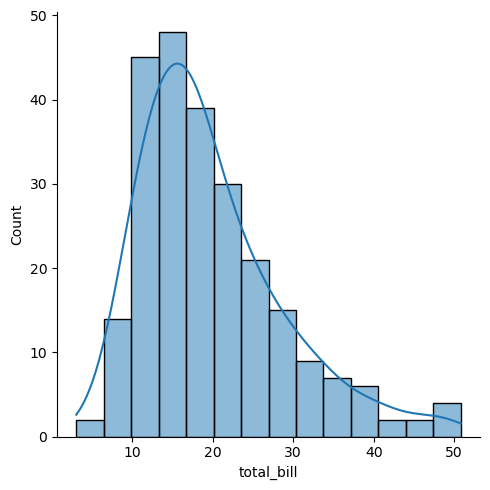

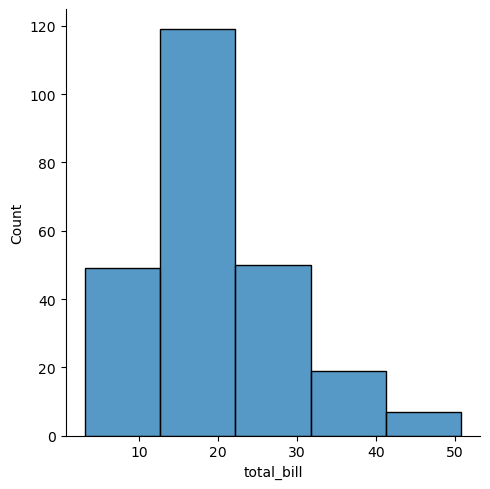

In [4]:
# sns.displot(a['total_bill'])  # default histogram
# sns.distplot(a['total_bill'])  # DEPRECATED, but used in older versions

# KDE (Kernel Density Estimate) -> Smooth bell curve over histogram
sns.displot(a['total_bill'], kde=True)

# Adjusting bin size
sns.displot(a['total_bill'], bins=5)

## 📝 NOTE: displot vs distplot vs histplot
displot: Figure-level, modern. Preferred method.

distplot: Deprecated. Earlier go-to for distributions.

histplot: Axes-level version of displot, gives finer control.

## 🧯 Subplot: Total Bill vs Tip Distribution

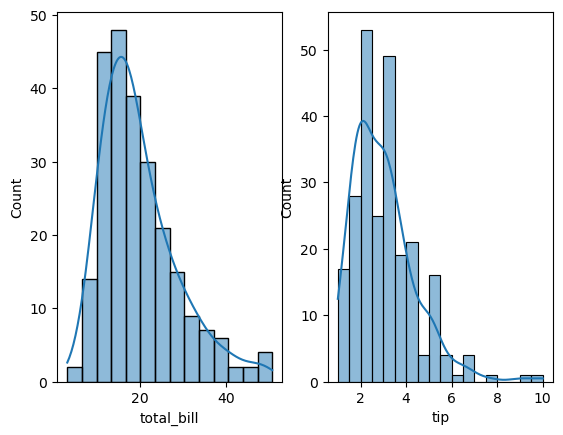

In [5]:
plt.subplot(1, 2, 1)
sns.histplot(a['total_bill'], kde=True)

plt.subplot(1, 2, 2)
sns.histplot(a['tip'], kde=True)
plt.show()


NOTE: plt.subplot() is similar to MATLAB’s subplot method.

## 🔗 Joint Plots (2D Distribution Plots)

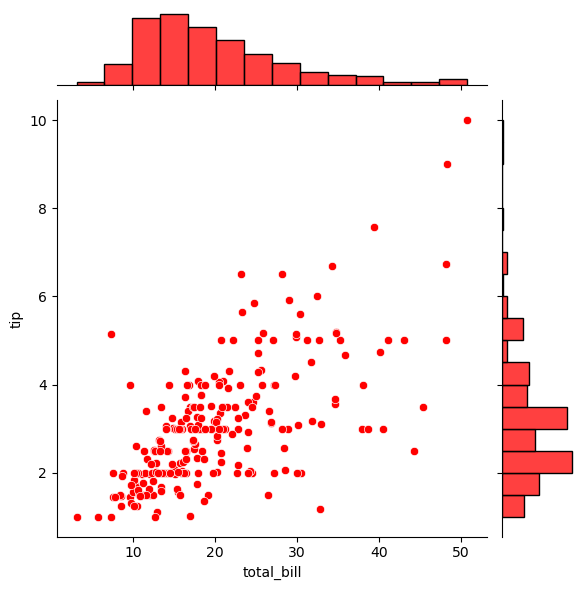

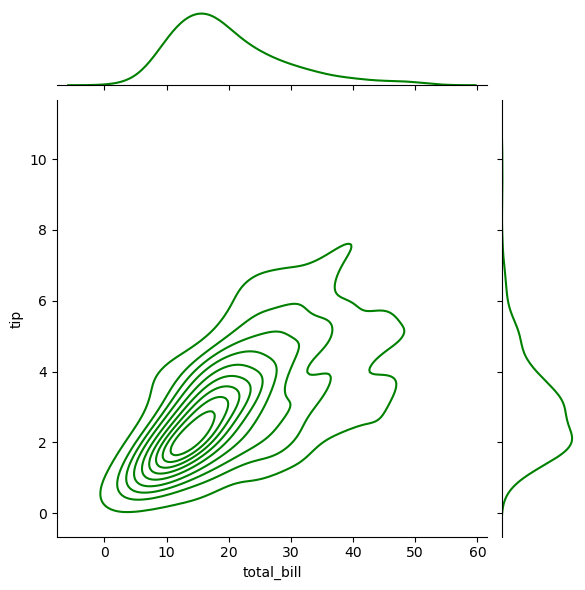

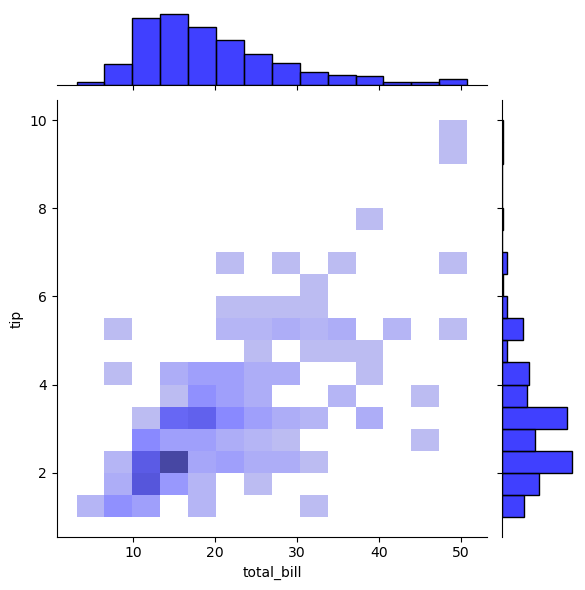

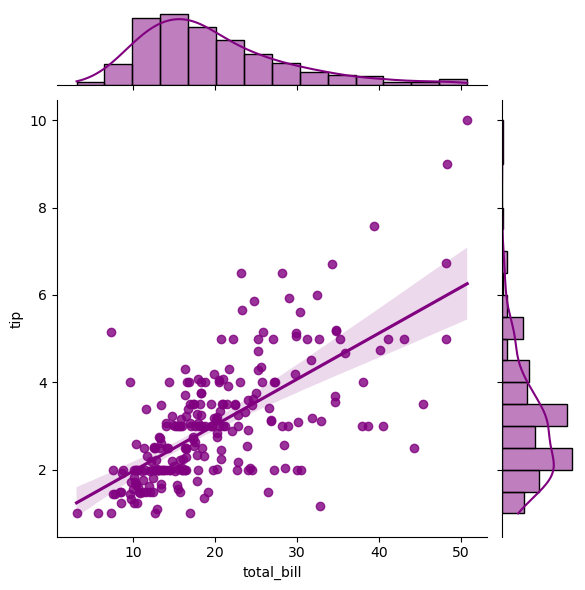

In [6]:
# Scatter between total_bill and tip
sns.jointplot(x='total_bill', y='tip', data=a, kind='scatter', color='red')

# KDE jointplot
sns.jointplot(x='total_bill', y='tip', data=a, kind='kde', color='green')

# Histogram style
sns.jointplot(x='total_bill', y='tip', data=a, kind='hist', color='blue')

# Regression line
sns.jointplot(x='total_bill', y='tip', data=a, kind='reg', color='purple')

## 🌐 Pair Plots (All Quantitative Relationships)


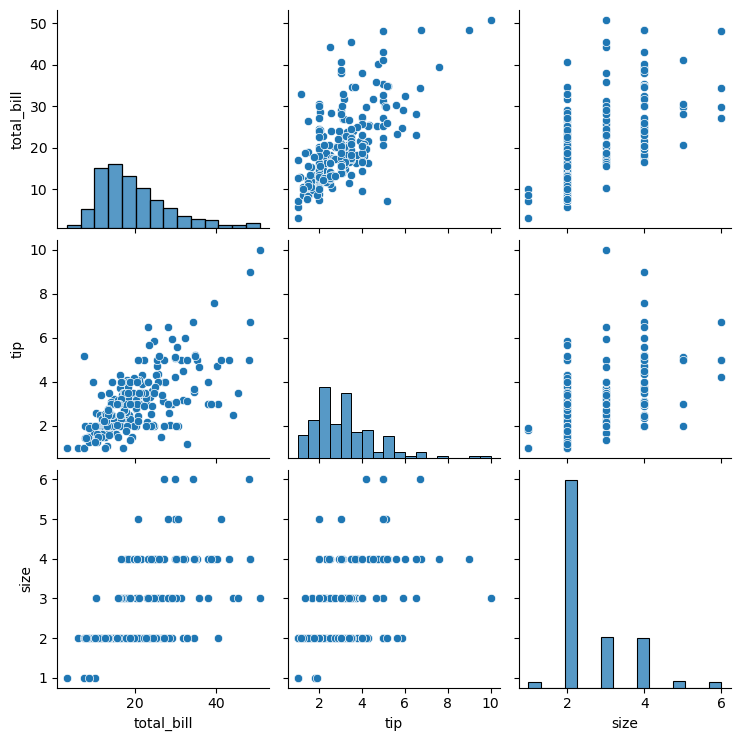

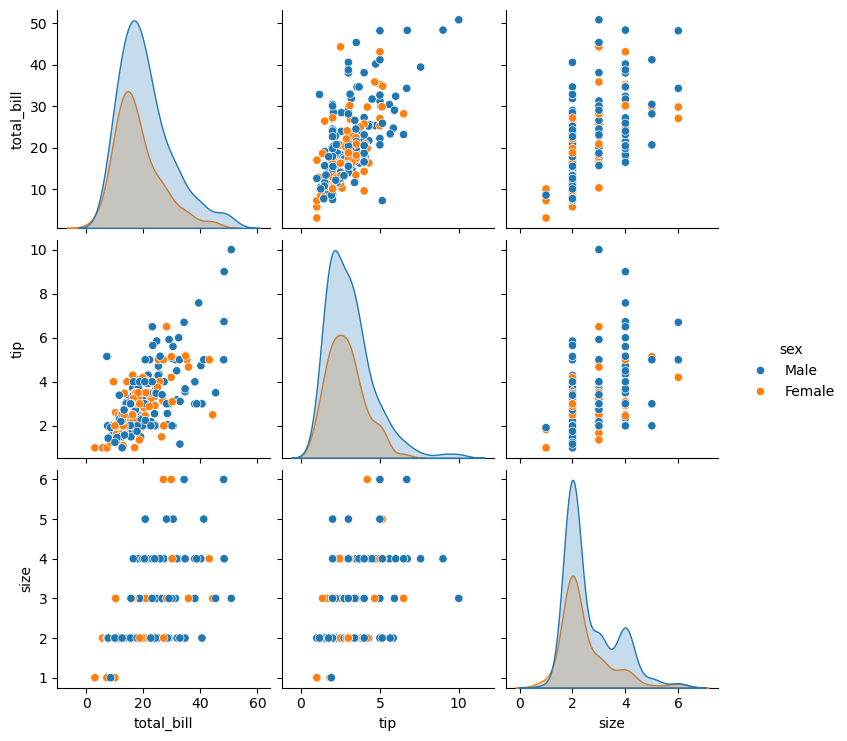

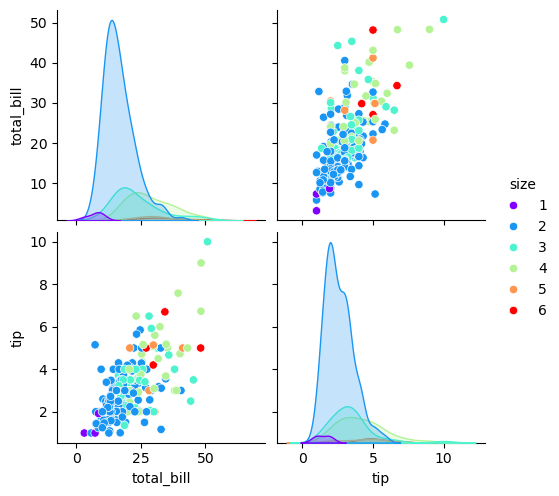

In [7]:
sns.pairplot(a)

# Colored by categorical column
sns.pairplot(a, hue='sex')
sns.pairplot(a, hue='size', palette='rainbow')

## 🧷 Rug Plot


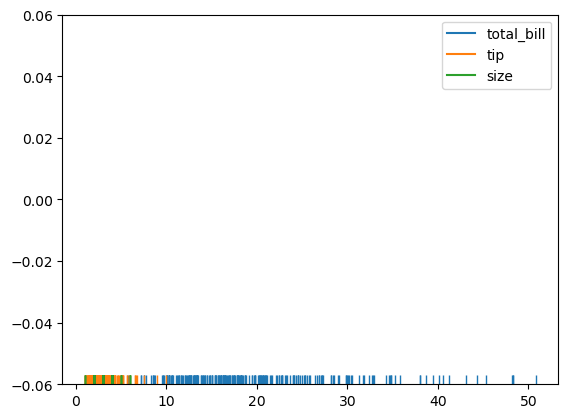

In [8]:
sns.rugplot(a)
plt.show()

## 🧊 Heatmaps & Matrix Plots

In [9]:
tip = sns.load_dataset("tips")
fly = sns.load_dataset("flights")

## 🔁 Pairplot vs Correlation Matrix

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


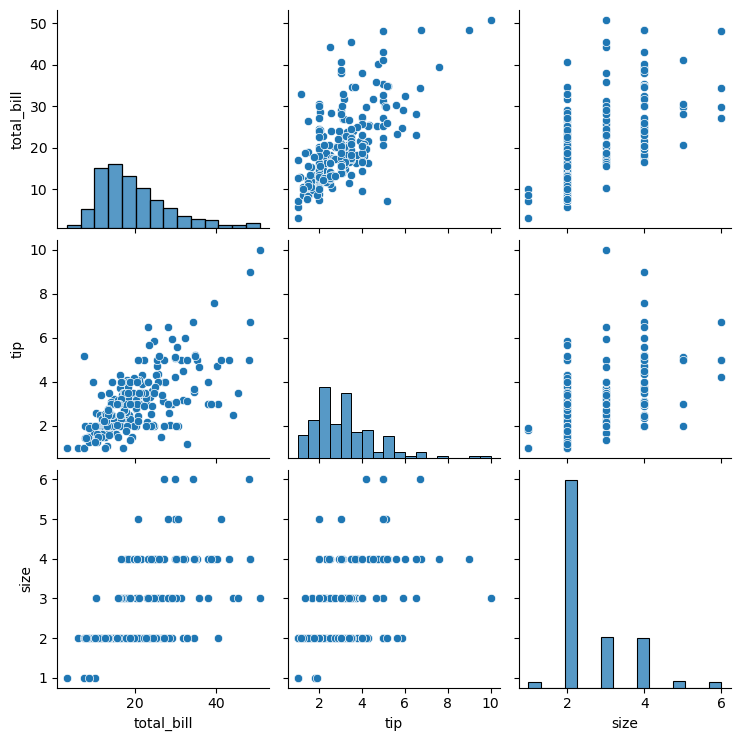

In [10]:
sns.pairplot(tip)
correlation_matrix = tip.corr(numeric_only=True)
print(correlation_matrix)

## 🔥 Heatmap with Annotations

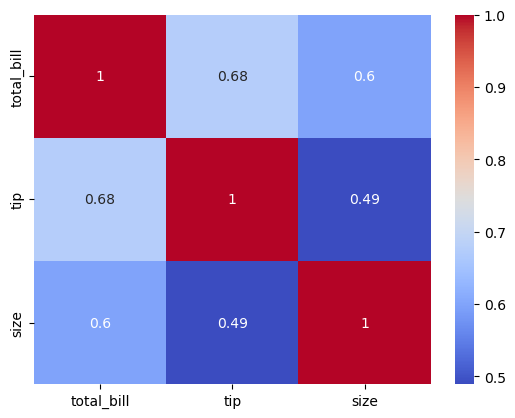

In [11]:
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.show()

🟦 clustermap and standard_scale
NOTE hey chatgpt , explain clustermap, standard_scale

✅ sns.clustermap()
Clusters similar rows and columns in a heatmap automatically.

Useful for grouping similar behavior (common in bioinformatics and ML).

Performs hierarchical clustering on rows and columns.


✅ standard_scale
Normalizes data before clustering:

standard_scale=0: scale columns

standard_scale=1: scale rows

## 🧮 Pivot Table & Cluster Map

C:\Users\wwwsh\AppData\Local\Temp\ipykernel_20560\2038735077.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pas = fly.pivot_table(index="month", columns="year", values="passengers")


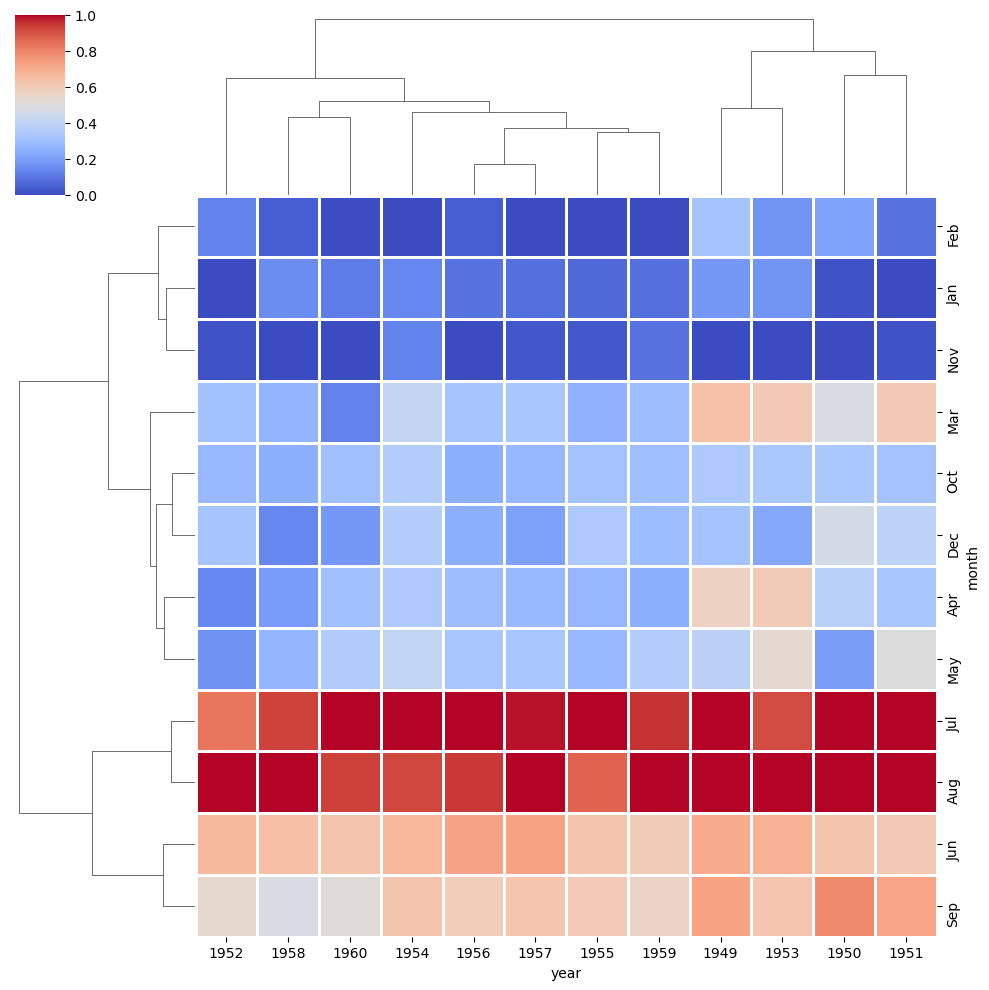

In [12]:
pas = fly.pivot_table(index="month", columns="year", values="passengers")

# Cluster map (groups similar rows/cols)
sns.clustermap(pas, cmap="coolwarm", linewidths=1, linecolor="white", standard_scale=1)
plt.show()

📝 NOTE:
clustermap: Automatically clusters similar rows and columns (based on hierarchical clustering).

standard_scale=1: Normalizes each column independently (like z-score standardization).

## 🌷 PairGrid (Custom Pairplot)

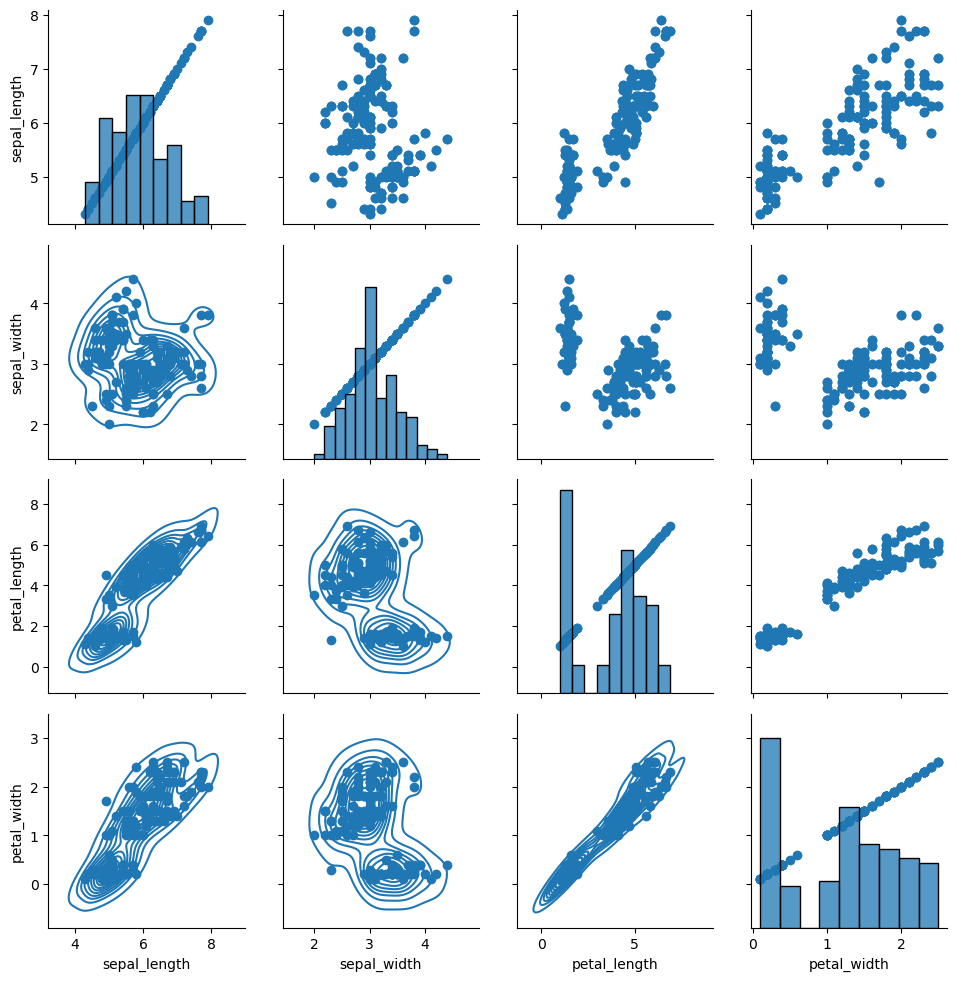

In [13]:
iris = sns.load_dataset("iris")
g = sns.PairGrid(iris)
g.map(plt.scatter)  # Scatter on all

g.map_diag(sns.histplot)  # Histogram on diagonal
g.map_lower(sns.kdeplot)
g.map_upper(plt.scatter)

## 🔀 FacetGrid (Split Plot Grid)

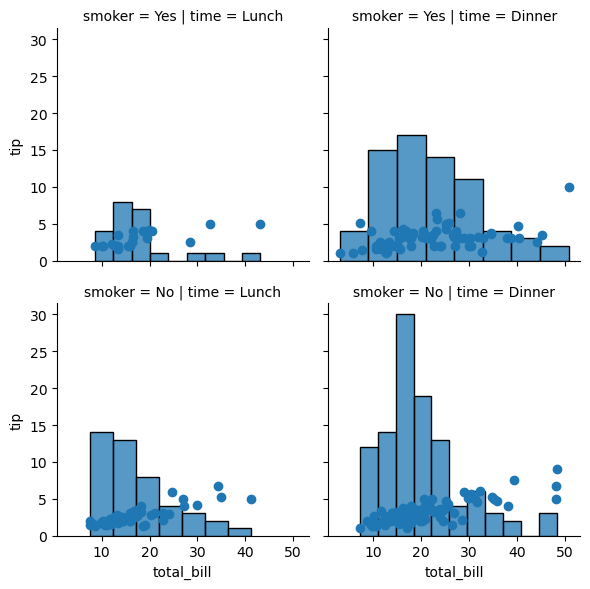

In [14]:
g = sns.FacetGrid(data=tip, col='time', row='smoker')
g.map(sns.histplot, 'total_bill')  # Histogram variant

# Using scatter instead
g.map(plt.scatter, 'total_bill', 'tip')


## 📈 Regression Plots

✅ scatter_kws
Allows you to customize the scatter points.

's': size of dots

'alpha': transparency

'color': manual color override

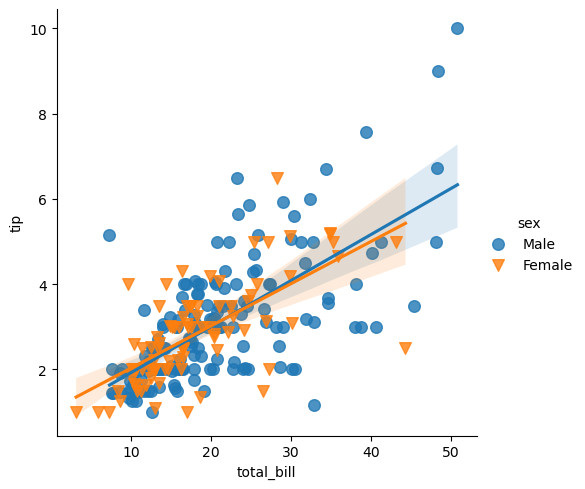

In [15]:
sns.lmplot(x='total_bill', y='tip', data=tip, hue='sex', markers=['o', 'v'], scatter_kws={'s': 70})

### 📝 Explanation:
markers: Custom symbols for hue groups.

scatter_kws: Dictionary for scatter plot style. 's' controls marker size.

🟦 lmplot – markers and scatter_kws
NOTE heyi chatgpt , explain markers and scatterkws

✅ markers
Changes the shape of the scatter dots per category in hue.

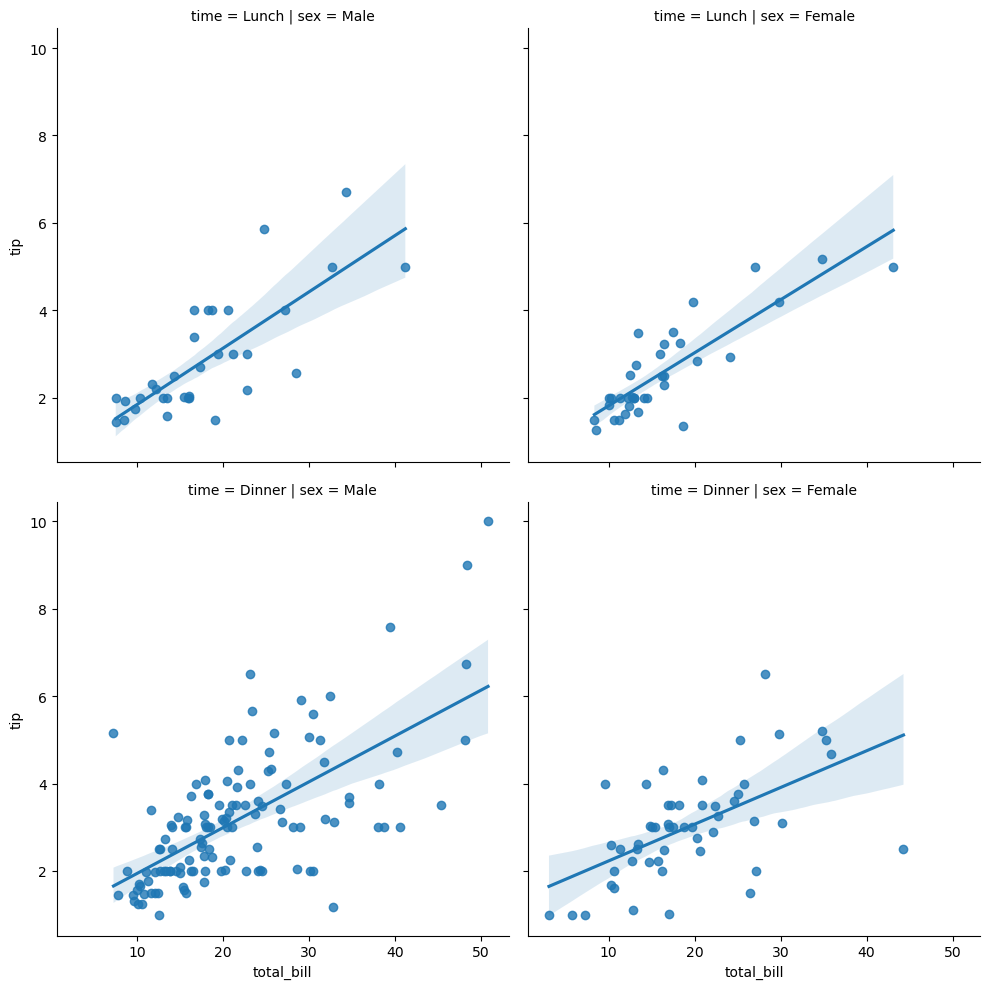

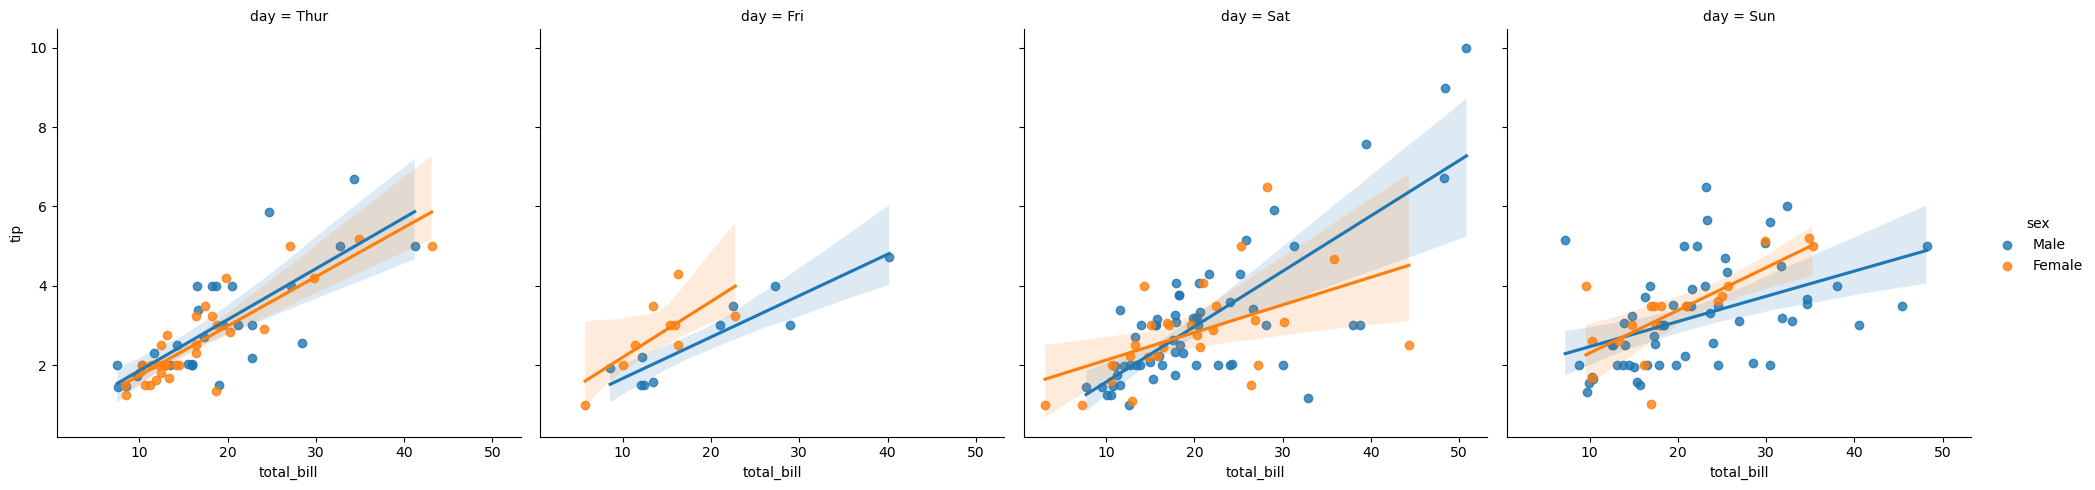

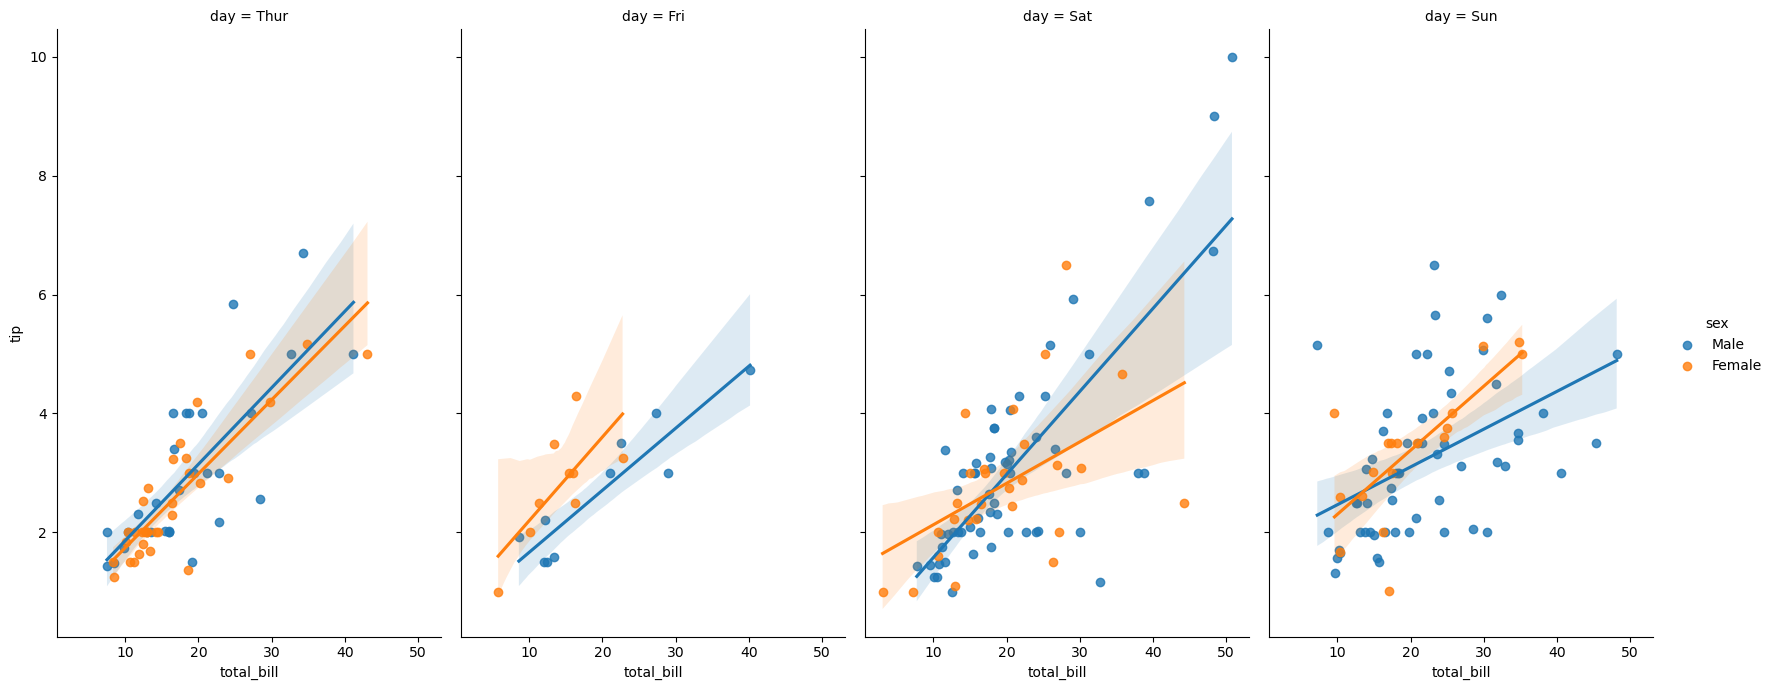

In [16]:
# Column-wise split
sns.lmplot(x='total_bill', y='tip', data=tip, col='sex', row='time')

# Hue + Col split
sns.lmplot(x='total_bill', y='tip', data=tip, col='day', hue='sex')

# Using aspect and height
sns.lmplot(x='total_bill', y='tip', data=tip, col='day', hue='sex', aspect=0.6, height=7)


aspect: Width ratio

height: Height of each plot (replaces deprecated size)

## 🎨 Styling Plots with Seaborn

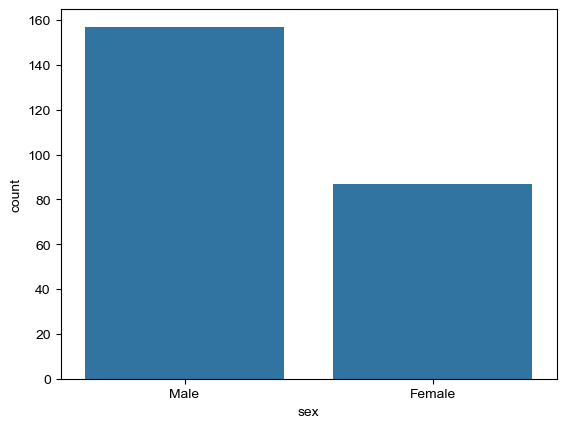

In [17]:
sns.countplot(x='sex', data=tip)

# Theme styles
sns.set_style('white')       # Minimalist
sns.set_style('darkgrid')    # Default grid
sns.set_style('whitegrid')   # Light with grid
sns.set_style('ticks')       # Ticks only
sns.set_style('dark')        # Dark background


 # NOTE -> for below stuff, run in python after loading dataset 

In [29]:
# Removing axis lines (spines)
sns.despine()  # Removes top and right
sns.despine(left=True, bottom=True)  # Removes all edges
plt.show()


<Figure size 640x480 with 0 Axes>

 # NOTE -> for below stuff, run in python after loading dataset 

## 🖼️ Figure Size and Font Context


Changes the scale of all fonts and elements (like legends, ticks).

Options: 'paper', 'notebook', 'talk', 'poster'

##  12 inches wide, 4 inches tall

In [30]:
plt.figure(figsize=(12, 4))  # Width = 12 inches, Height = 4 inches

sns.set_context('poster')  # Use preset font scaling for presentation
sns.set_context('poster', font_scale=3)  # Manually increase font size
plt.show()

<Figure size 1200x400 with 0 Axes>

## 🌈 Color Palettes and Colormaps

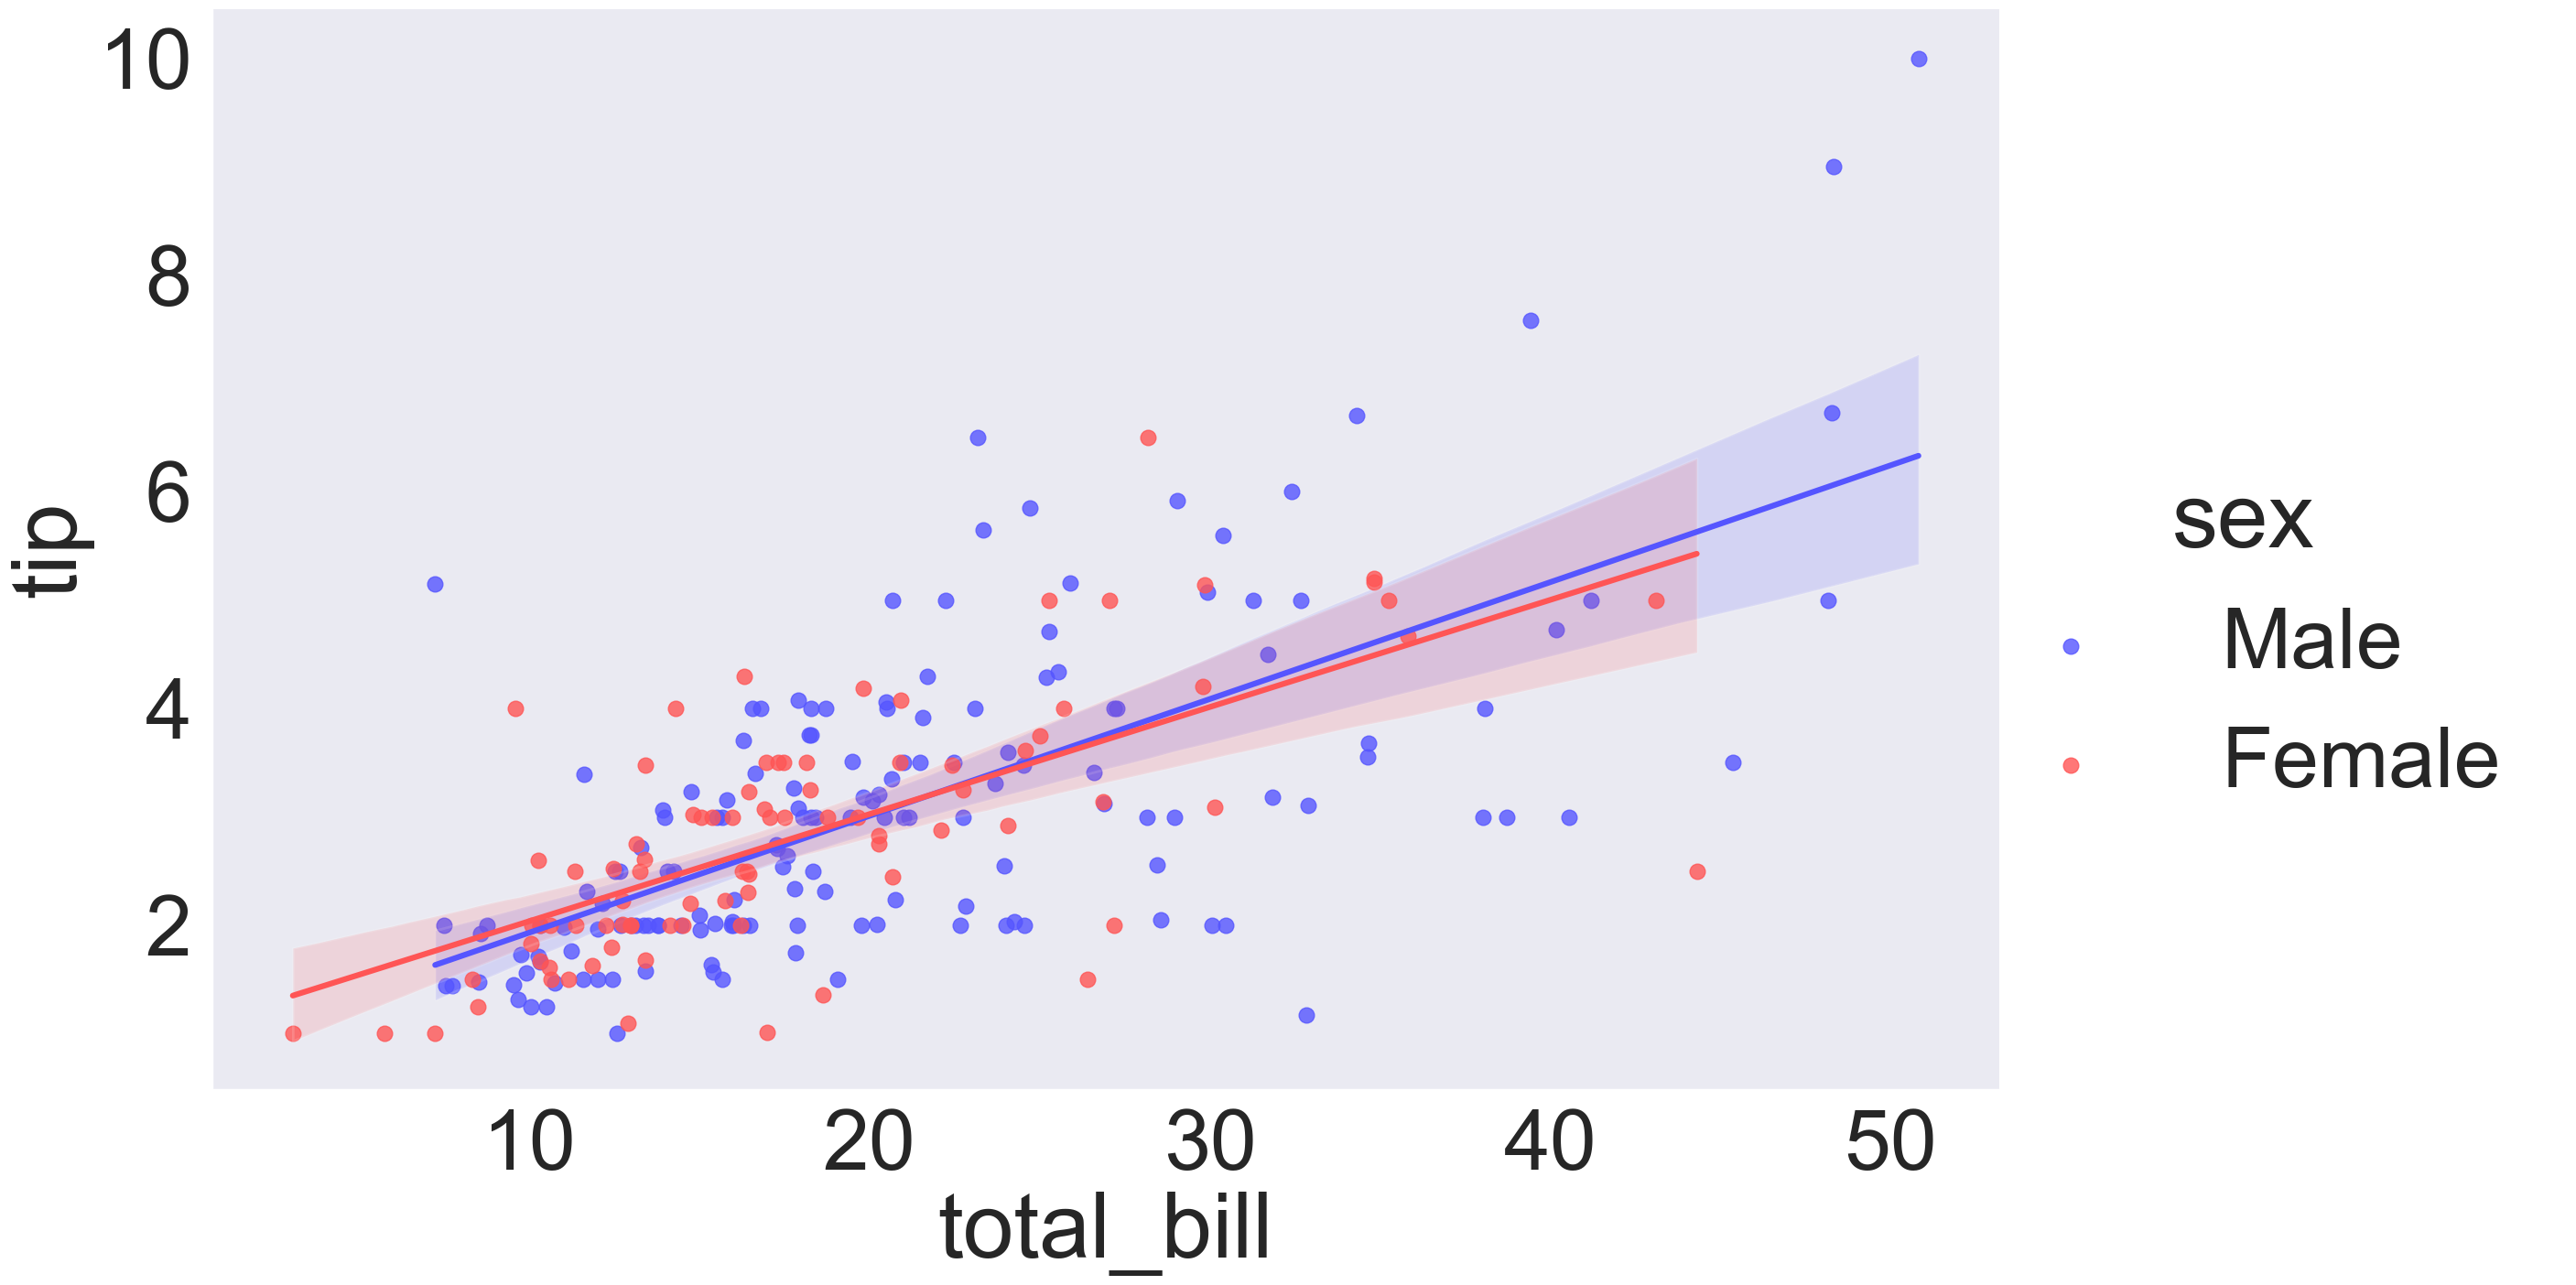

In [27]:
sns.lmplot(x='total_bill', y='tip', data=tip, hue='sex', palette='seismic', height=16, aspect=1.5)


🎨 Popular Seaborn Palettes:
'deep' (default)

'muted'

'bright'

'pastel'

'dark'

'colorblind'

'husl'

'cubehelix'

'Set1', 'Set2', 'Set3'

'seismic', 'coolwarm', 'magma', 'inferno', 'plasma', 'cividis'

# 🎨 Seaborn Color Palettes

| Palette Name    | Description                    |
|----------------|--------------------------------|
| deep           | Default, distinct and rich     |
| muted          | Softer than deep               |
| bright         | Vivid and high contrast        |
| pastel         | Light and soft tones           |
| dark           | Deeper tones for contrast      |
| colorblind     | Colorblind-friendly palette    |
| husl           | Circular hue palette (vivid)   |
| hls            | Hue-lightness-saturation       |
| cubehelix      | Perceptually uniform palette   |
| Set1           | From matplotlib's Set1         |
| Set2           | Softer categorical colors      |
| Set3           | Large variety, categorical     |
| Accent         | For accented categories        |
| Paired         | Color pairs for comparisons    |
| Pastel1        | Very soft pastel shades        |
| Pastel2        | Soft but varied colors         |
| Dark2          | Categorical, dark tones        |
| tab10          | 10-color matplotlib set        |
| tab20          | 20-color matplotlib set        |
| tab20b         | Alternative 20-color set       |
| tab20c         | Another 20-color variant       |



# 🌈 Matplotlib Colormaps
| Colormap Name  | Type       | Description                          |
|----------------|------------|--------------------------------------|
| viridis        | Sequential | Default perceptual colormap          |
| plasma         | Sequential | Bright, high contrast                |
| inferno        | Sequential | Dark with high contrast              |
| magma          | Sequential | Deep and warm                       |
| cividis        | Sequential | Colorblind-safe                     |
| rocket         | Sequential | Red–black gradient (Seaborn)         |
| mako           | Sequential | Blue–black gradient (Seaborn)        |
| icefire        | Diverging  | Cool-warm perceptual split (Seaborn) |
| coolwarm       | Diverging  | Red to blue gradient                |
| Spectral       | Diverging  | Full-spectrum heatmap colors         |
| rainbow        | Cyclic     | Intense rainbow cycle                |
| seismic        | Diverging  | Red–white–blue                      |
| YlGnBu         | Sequential | Yellow-Green-Blue scale              |
| YlOrRd         | Sequential | Yellow-Orange-Red scale              |
| Greens         | Sequential | Various greens                      |
| Blues          | Sequential | Various blues                       |
| Oranges        | Sequential | Various oranges                     |
| Purples        | Sequential | Various purples                     |
| Reds           | Sequential | Various reds                        |
